# Tahim Bhuiya

# Part 4: Unsupervised Learning & Final Report

In [1]:
import pandas as pd
df = pd.read_csv('Airline_Delay_Cause.csv')
df

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318012,2003,6,DL,Delta Air Lines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,...,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
318013,2003,6,DL,Delta Air Lines Inc.,SFO,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,...,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
318014,2003,6,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,...,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
318015,2003,6,DL,Delta Air Lines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,...,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0


In [2]:
df.columns # print the columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [3]:
df.shape # print the number of rows and columns

(318017, 21)

In [4]:
df = df.dropna() # remove rows containing nan values

In [5]:
df = df.drop_duplicates(keep='first') # drop duplicated rows, keep the first occurrence

In [6]:
df.shape

(317261, 21)

In [7]:
import pandas as pd

# Create high/low delay category based on median of arr_del15
delay_threshold = df['arr_del15'].median()
df['delay_category'] = df['arr_del15'] > delay_threshold  # True = High delay, False = Low delay

In [8]:
# Create high/low weather-delay category based on median of weather_ct that will be used as a feature
weather_threshold = df['weather_ct'].median()
df['weather_category'] = df['weather_ct'] > weather_threshold  # True = High weather delay, False = Low

In [9]:
# Convert weather_category (True/False) → (1/0)
df['weather_category'] = df['weather_category'].astype(int)

# Principal Component Analysis (PCA)

## Starting by using the same features that you used for fitting the model in Part 3.

In [10]:
# Select X and y
X = df[['month', 'arr_flights', 'carrier_ct', 'nas_delay', 
            'late_aircraft_ct', 'security_delay', 'weather_category']]
y = df['delay_category'].astype(int)

## Standardize the features using StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.43302755, -0.23947506, -0.31746639, ..., -0.31865986,
        -0.18576804, -0.99943595],
       [-0.43302755, -0.28326954, -0.28747941, ..., -0.25106675,
        -0.18576804, -0.99943595],
       [-0.43302755, -0.3533407 , -0.43951129, ..., -0.32025341,
        -0.18576804, -0.99943595],
       ...,
       [-0.14401609, -0.22974295, -0.29565767, ..., -0.30338833,
        -0.18576804, -0.99943595],
       [-0.14401609, -0.2793767 , -0.36548749, ..., -0.31308244,
        -0.18576804, -0.99943595],
       [-0.14401609,  3.00131635,  2.09826785, ...,  1.02696097,
         0.53457538,  1.00056436]])

## Fitting PCA to the standardized features and plot the explained variance ratio for each component. Select enough components to explain at least 90% of the total variance.

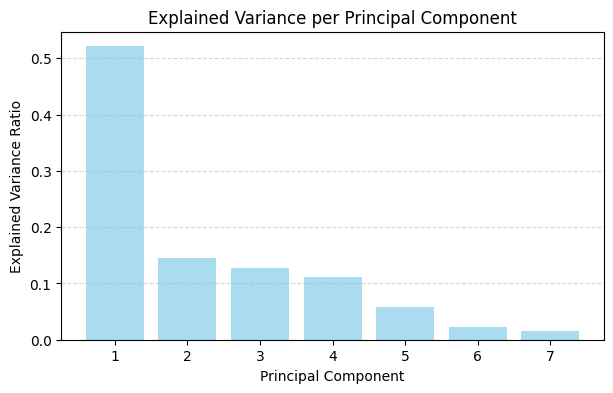

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Explained variance per component
explained_variance_ratio = pca.explained_variance_ratio_

# Plot explained variance per component
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, color='skyblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


Using 4 components would bring us to the 90% mark we are looking for, but we will show the use of 3 and 2 components for the visualization.

## Transform the standardized features using the selected number of components. For visualization, use the first 2 or 3 principal components, even if you retained more

In [13]:
pca = PCA(n_components=3) #using 3 components for visualization
X_pca = pca.fit_transform(X_scaled)

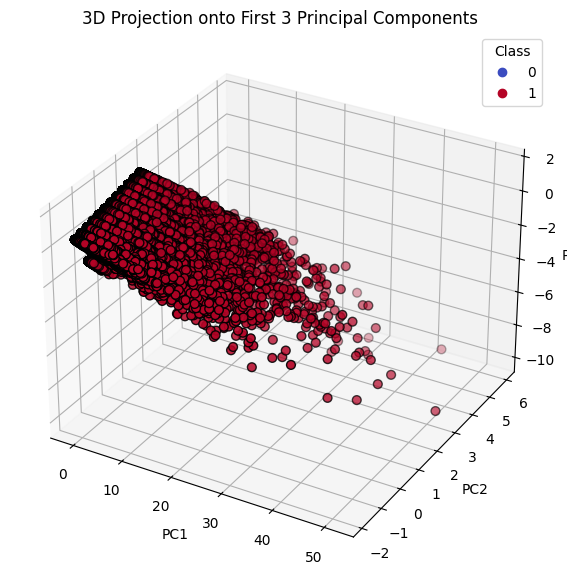

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# You can color by known labels or by clusters if you’ve run KMeans
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=y,  # or use cluster_labels
    cmap='coolwarm', edgecolor='k', s=40
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D Projection onto First 3 Principal Components')
plt.legend(*scatter.legend_elements(), title="Class")
plt.show()

### Here is what it would look like if we would do 2 principal components

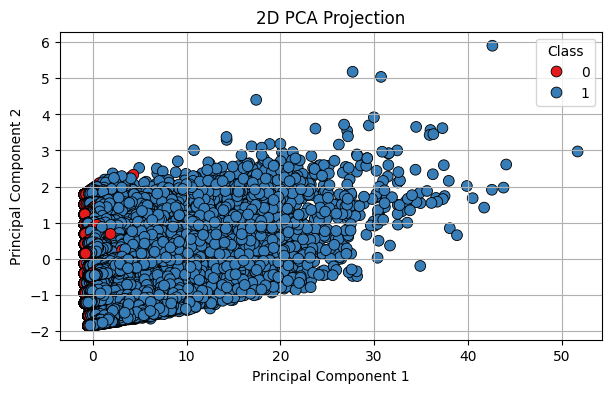

In [15]:
import seaborn as sns

pca = PCA(n_components=2)  # using 2 components for visualization
X_pca_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 4))
sns.scatterplot( x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y,  palette='Set1', s=60,edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection')
plt.legend(title='Class')
plt.grid(True)
plt.show()

## Split the transformed dataset (after PCA was applied) into training and testing.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
pca = PCA(n_components=4) #using 4 components to get the 90% variance mark
X_pca_4 = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca_4, y, test_size=0.2)

## Training a logistic regression classifier on the PCA-transformed training data using 5- fold cross-validation.

In [18]:
model = LogisticRegression()

# Accuracy
acc_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

# F1 score
f1_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')


## Reporting the average F1 and accuracy across 5 folds.

In [19]:
print("Average CV Accuracy:", acc_scores.mean())
print("Average CV F1 Score:", f1_scores.mean())

Average CV Accuracy: 0.9568807940730825
Average CV F1 Score: 0.9554730507940865


## Fitting and evaluating the model on the testing dataset and report F1 and accuracy

In [20]:
from sklearn.metrics import accuracy_score, f1_score

# Train on full training data
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test F1 Score:", test_f1)

Test Accuracy: 0.9575591382598143
Test F1 Score: 0.9563752409648313


In [21]:
# Classification Report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     32443
           1       0.96      0.95      0.96     31010

    accuracy                           0.96     63453
   macro avg       0.96      0.96      0.96     63453
weighted avg       0.96      0.96      0.96     63453



# K-Means Clustering

## Performing K-Means clustering on the standardized dataset (all the features) and plot inertia for k values 1-10

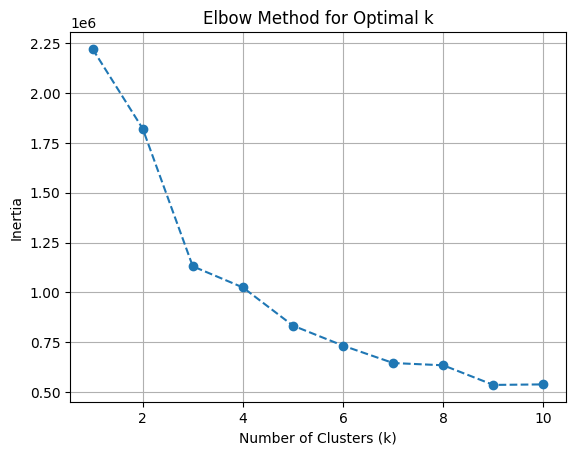

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid()
plt.show()

## Using Elbow method, what is the sufficient number of clusters?

The plot shows a sharp decrease in inertia up to k = 4, and then we can see that the rate of decrease slows down significantly. This indicates that adding more clusters beyond k = 4  wouldn't be a good choice. Because of this, k = 4 will be used as the number of clusters. 

## Fitting K-means one more time using the selected K.

In [23]:
final_kmeans = KMeans(n_clusters=4)
cluster_labels = final_kmeans.fit_predict(X_scaled)

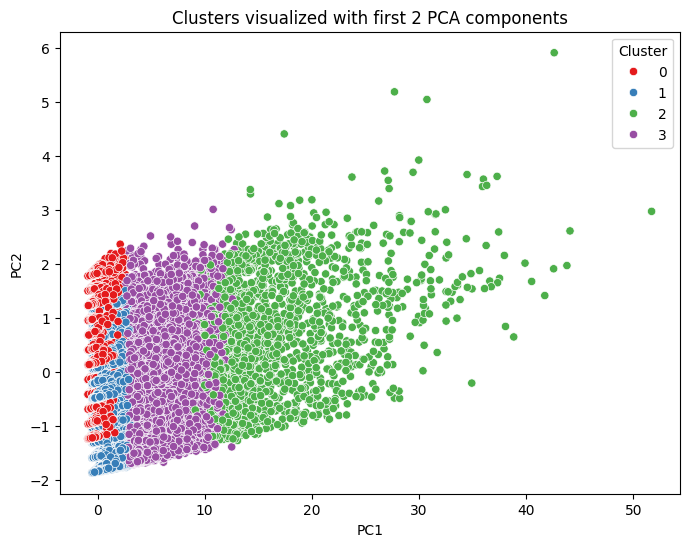

In [24]:
# 2D PCA for visualization
X_2D = X_pca[:, :2]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=cluster_labels, palette='Set1')
plt.title('Clusters visualized with first 2 PCA components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()